# euclid_cutouts — Tutorial

This notebook shows how to use the `euclid_cutouts` library to produce colour
cutout images from Euclid data. Three workflows are demonstrated:

1. **Single cutout** — render one (4, H, W) IYJH array through azulero / bulk_euclid
2. **FITS-input mode** — batch-render a directory of pre-made FITS cutout files
3. **ML-inference loop** — load FITS cutouts on the fly, run a classifier, and
   keep only the high-confidence detections (FITS + colour images)

## Install

```bash
pip install -e /media/user/euclid_cutouts
```

In [1]:
import os
import numpy as np
from astropy.io import fits
from PIL import Image

from euclid_cutouts import (
    load_fits_cutout,
    render_azulero,
    render_bulk_variant,
    render_cutout,
    render_fits_dir,
)

# Paths to the local clones — needed so the renderers can find azulero_render
# and the bulk_euclid utilities. Adjust if yours are elsewhere.
CUTANA_ROOT = "/media/user/astronomaly-euclid"
BULK_ROOT   = "/media/user/bulk-euclid-cutouts"

## 1. Render a single cutout

`render_cutout` takes a `(4, H, W)` IYJH float32 array (band order: VIS,
NIR-Y, NIR-J, NIR-H) and returns a dict of `{name: (H, W, 3) uint8 RGB}`
arrays — one per enabled renderer/variant.

Here we load a real grade-A strong-lens candidate from Q1
(EUCL J035713.80-475646.7, Bergamini+25) from the `demo_fits/` directory.

Loaded demo_fits/EUCL_J035713_lens.fits
  shape=(4, 101, 101)  dtype=float32
  VIS: min=0.0052  max=3.8351
  NIR_Y: min=0.0000  max=715.0354
  NIR_J: min=2.6930  max=1237.5845
  NIR_H: min=3.5672  max=1112.6912



Renderers produced: ['azulero', 'gz_arcsinh_vis_y', 'sw_mtf_vis_y_j']


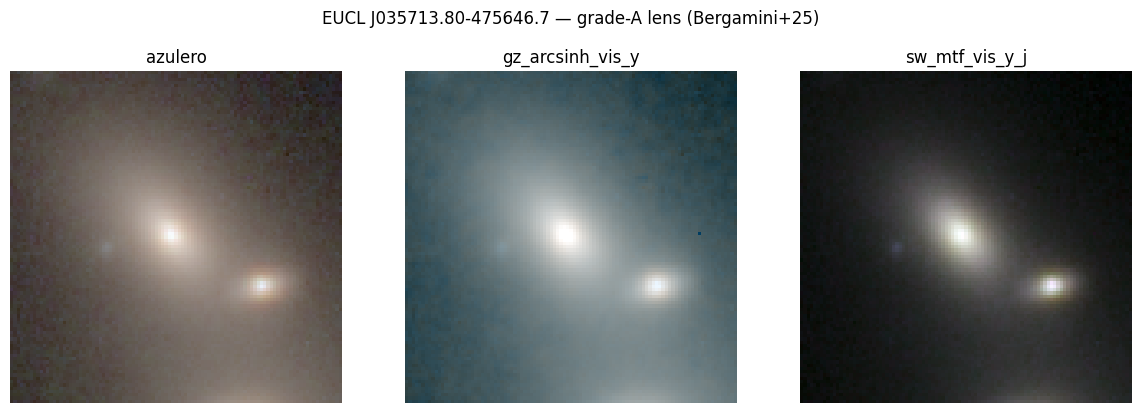

In [2]:
# Load a real Q1 lens cutout (4-band FITS extracted from tile 102021494)
DEMO_DIR = os.path.join(os.path.dirname(os.getcwd()), "demo_fits")
if not os.path.isdir(DEMO_DIR):
    DEMO_DIR = "demo_fits"

lens_path = os.path.join(DEMO_DIR, "EUCL_J035713_lens.fits")
iyjh = load_fits_cutout(lens_path, band_order=["VIS", "NIR_Y", "NIR_J", "NIR_H"])
print(f"Loaded {lens_path}")
print(f"  shape={iyjh.shape}  dtype={iyjh.dtype}")
for i, b in enumerate(["VIS", "NIR_Y", "NIR_J", "NIR_H"]):
    print(f"  {b}: min={iyjh[i].min():.4f}  max={iyjh[i].max():.4f}")

# Render through all available stretches at once
results = render_cutout(
    iyjh,
    renderers=["azulero", "bulk_euclid"],
    bulk_variants=["gz_arcsinh_vis_y", "sw_mtf_vis_y_j"],
    cutana_root=CUTANA_ROOT,
    bulk_euclid_root=BULK_ROOT,
)

print("\nRenderers produced:", list(results.keys()))

# Display side by side
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4))
if len(results) == 1:
    axes = [axes]
for ax, (name, rgb) in zip(axes, results.items()):
    ax.imshow(rgb, origin="upper")
    ax.set_title(name)
    ax.axis("off")
plt.suptitle("EUCL J035713.80-475646.7 — grade-A lens (Bergamini+25)", y=1.02)
plt.tight_layout()
plt.show()

### Using a single renderer

You don't have to run all colour stretches — just pass the one you want.
`render_azulero` and `render_bulk_variant` work on individual cutouts:

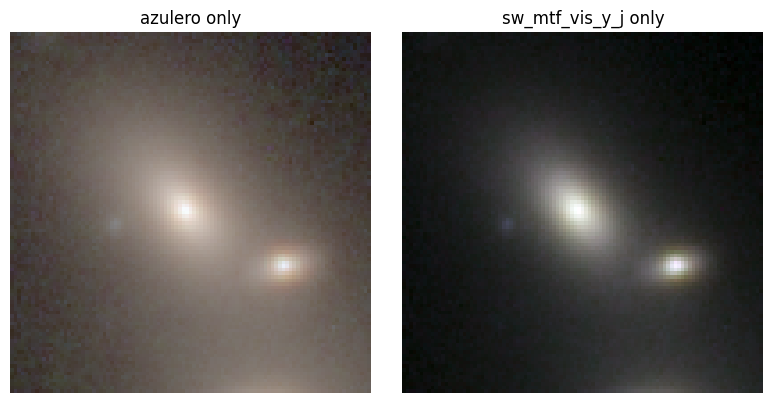

Keys: ['gz_arcsinh_vis_y']


In [3]:
# Azulero only
rgb_azulero = render_azulero(iyjh, cutana_root=CUTANA_ROOT)

# Or a single bulk_euclid variant
rgb_mtf = render_bulk_variant("sw_mtf_vis_y_j",
                              iyjh[0], iyjh[1], iyjh[2],
                              bulk_euclid_root=BULK_ROOT)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(rgb_azulero); axes[0].set_title("azulero only"); axes[0].axis("off")
axes[1].imshow(rgb_mtf);     axes[1].set_title("sw_mtf_vis_y_j only"); axes[1].axis("off")
plt.tight_layout()
plt.show()

# render_cutout also accepts a single renderer:
out = render_cutout(iyjh, renderers=["bulk_euclid"],
                    bulk_variants=["gz_arcsinh_vis_y"],
                    bulk_euclid_root=BULK_ROOT)
print("Keys:", list(out.keys()))  # only gz_arcsinh_vis_y — no azulero

## 2. Batch-render a directory of FITS cutouts

`render_fits_dir` batch-processes a folder of FITS cutout files. Here we use
`demo_fits/` which contains 3 real grade-A Q1 lens candidates:

- EUCL J035713.80-475646.7 (Bergamini+25)
- EUCL J033036.29-294946.3 (Bergamini+25)
- EUCL J040408.75-460534.5 (Ecker+25)

In [4]:
# demo_fits/ already contains 3 real Q1 lens cutouts (4-band IYJH)
print("Input FITS files:")
for fn in sorted(os.listdir(DEMO_DIR)):
    if fn.endswith(".fits"):
        print(f"  {fn}")

Input FITS files:
  EUCL_J033036_lens.fits
  EUCL_J035713_lens.fits
  EUCL_J040408_lens.fits


In [5]:
import shutil

demo_out_dir = "demo_output"
shutil.rmtree(demo_out_dir, ignore_errors=True)

totals = render_fits_dir(
    input_dir=DEMO_DIR,
    output_dir=demo_out_dir,
    enable_azulero=True,
    enable_bulk_euclid=True,
    bulk_variants=["gz_arcsinh_vis_y", "sw_mtf_vis_y_j"],
    band_order=["VIS", "NIR_Y", "NIR_J", "NIR_H"],
    fmt="jpg",
    jpeg_quality=95,
    n_workers=1,
    progress_bar=True,
    cutana_root=CUTANA_ROOT,
    bulk_euclid_root=BULK_ROOT,
)

print("\nTotals:", totals)
print("\nOutput tree:")
for root, dirs, files in os.walk(demo_out_dir):
    level = root.replace(demo_out_dir, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files):
        print(f"{indent}  {f}")

Rendering FITS cutouts:   0%|                                                                                                                                                                                 | 0/3 [00:00<?, ?file/s]

Rendering FITS cutouts:   0%|                                                                                                                                | 0/3 [00:00<?, ?file/s, azulero=1  gz_arcsinh_vis_y=1  sw_mtf_vis_y_j=1]

Rendering FITS cutouts:   0%|                                                                                                                                | 0/3 [00:00<?, ?file/s, azulero=2  gz_arcsinh_vis_y=2  sw_mtf_vis_y_j=2]

Rendering FITS cutouts:   0%|                                                                                                                                | 0/3 [00:00<?, ?file/s, azulero=3  gz_arcsinh_vis_y=3  sw_mtf_vis_y_j=3]

Rendering FITS cutouts: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 13.55file/s, azulero=3  gz_arcsinh_vis_y=3  sw_mtf_vis_y_j=3]

Rendering FITS cutouts: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 13.51file/s, azulero=3  gz_arcsinh_vis_y=3  sw_mtf_vis_y_j=3]


Totals: {'azulero': 3, 'gz_arcsinh_vis_y': 3, 'sw_mtf_vis_y_j': 3}

Output tree:
demo_output/
  azulero/
    EUCL_J033036_lens.jpg
    EUCL_J035713_lens.jpg
    EUCL_J040408_lens.jpg
  gz_arcsinh_vis_y/
    EUCL_J033036_lens.jpg
    EUCL_J035713_lens.jpg
    EUCL_J040408_lens.jpg
  sw_mtf_vis_y_j/
    EUCL_J033036_lens.jpg
    EUCL_J035713_lens.jpg
    EUCL_J040408_lens.jpg


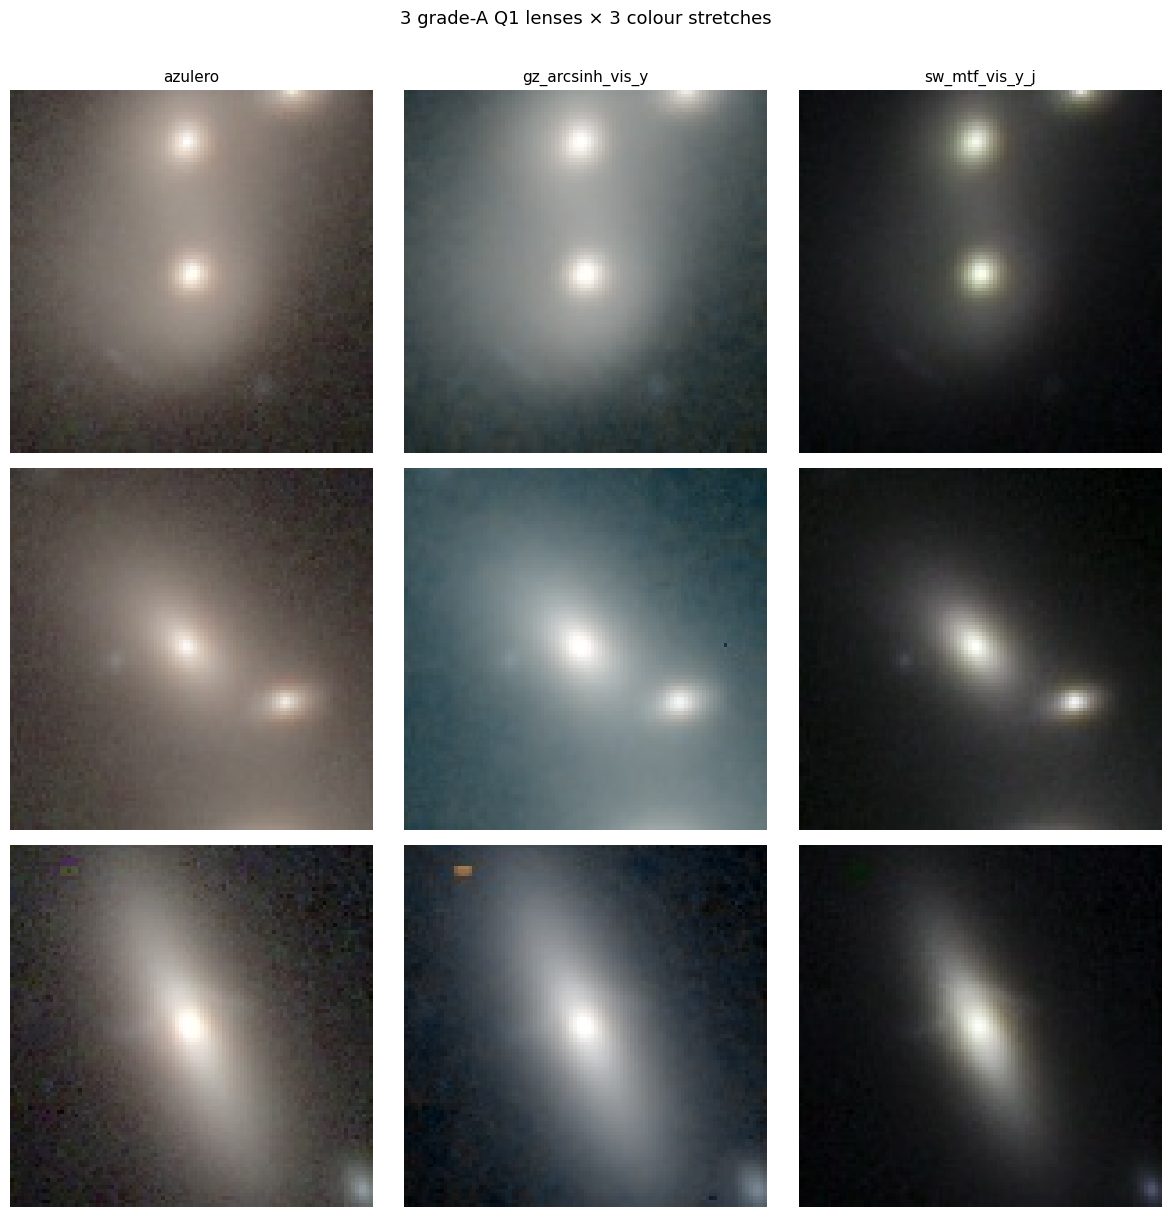

In [6]:
# Display all 3 lenses x 3 renderers
variants = ["azulero", "gz_arcsinh_vis_y", "sw_mtf_vis_y_j"]
stems = sorted(os.path.splitext(f)[0] for f in os.listdir(DEMO_DIR) if f.endswith(".fits"))

fig, axes = plt.subplots(len(stems), len(variants),
                         figsize=(4 * len(variants), 4 * len(stems)))
for row, stem in enumerate(stems):
    for col, var in enumerate(variants):
        img_path = os.path.join(demo_out_dir, var, f"{stem}.jpg")
        axes[row, col].imshow(Image.open(img_path))
        if row == 0:
            axes[row, col].set_title(var, fontsize=11)
        if col == 0:
            axes[row, col].set_ylabel(stem.replace("_lens", ""), fontsize=9)
        axes[row, col].axis("off")
plt.suptitle("3 grade-A Q1 lenses × 3 colour stretches", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### About `band_order`

Multi-extension FITS cutout files store each band as a separate HDU
(CHANNEL_1, CHANNEL_2, ...), but different tools write the bands in different
orders. `band_order` tells the loader which band each extension corresponds to:

```
CHANNEL_1 → band_order[0]
CHANNEL_2 → band_order[1]
...
```

The loader maps each band to its slot in the internal (4, H, W) IYJH array:
VIS → index 0, NIR_Y → 1, NIR_J → 2, NIR_H → 3. Bands not present in the
FITS file are zero-filled.

| Source of FITS cutouts | `band_order` to use |
|---|---|
| This pipeline's `demo_fits/` | `["VIS", "NIR_Y", "NIR_J", "NIR_H"]` (default) |
| Cutana 3-band (workspace convention) | `["NIR_Y", "NIR_J", "VIS"]` |
| Single-band VIS-only | `["VIS"]` |

```python
# Cutana 3-band example
totals = render_fits_dir(
    input_dir="/path/to/cutana_output",
    output_dir="cutouts",
    band_order=["NIR_Y", "NIR_J", "VIS"],
    enable_azulero=True,
    cutana_root=CUTANA_ROOT,
)
```

## 3. CSV-mode (tile-based pipeline via CLI)

The original tile-based pipeline reads a CSV of sources, resolves tiles via
HEALPix, loads full tile FITS, extracts cutouts, and renders through all four
colour stretches (azulero, eummy, bulk_euclid). This mode also supports eummy,
which needs tile-level FITS on disk.

Run from the terminal:

```bash
# Edit the CONFIG block at the top of the script first, then:
python scripts/make_colour_cutouts.py
```

Or switch to FITS-input mode from the same script by setting
`INPUT_FITS_DIR` in the CONFIG block — the script then calls `render_fits_dir`
internally.

## 4. ML-inference loop — render on the fly, keep high-confidence detections

This is the key use case for the library API: you have a trained classifier
(e.g. a strong-lens finder) and a directory of FITS cutouts.  You want to:

1. Load each FITS cutout
2. Run your model on the raw array (or on a rendered RGB)
3. **Only if** the predicted probability exceeds a threshold, save the
   original FITS **and** the colour images

This avoids rendering and saving thousands of uninteresting cutouts.

In [7]:
def ml_filter_and_render(
    fits_dir: str,
    output_dir: str,
    predict_fn,
    *,
    threshold: float = 0.5,
    band_order: list[str] | None = None,
    renderers: list[str] | None = None,
    bulk_variants: list[str] | None = None,
    fmt: str = "jpg",
    jpeg_quality: int = 95,
    save_fits: bool = True,
    cutana_root: str | None = None,
    bulk_euclid_root: str | None = None,
):
    """Load FITS cutouts, run an ML model, and save only high-confidence hits.

    Parameters
    ----------
    fits_dir : directory of .fits cutout files.
    output_dir : root output dir. Colour images go into subdirs per renderer;
        FITS copies go into ``output_dir/fits/``.
    predict_fn : callable(iyjh) -> float.  Receives a (4, H, W) float32 array,
        returns a scalar probability (0–1).  This is your model.
    threshold : minimum probability to keep a cutout.
    band_order : FITS extension-to-band mapping (default 4-band IYJH).
    renderers : list of renderers ("azulero", "bulk_euclid").
    bulk_variants : which bulk_euclid variants to produce.
    fmt : output image format ("jpg" or "png").
    jpeg_quality : JPEG quality.
    save_fits : if True, copy the original FITS file into output_dir/fits/.
    cutana_root : path to astronomaly-euclid.
    bulk_euclid_root : path to bulk-euclid-cutouts.

    Returns
    -------
    results : list of dicts with keys: stem, fits_path, probability, kept.
    """
    import glob, shutil

    if renderers is None:
        renderers = ["azulero", "bulk_euclid"]
    if bulk_variants is None:
        bulk_variants = ["gz_arcsinh_vis_y", "sw_mtf_vis_y_j"]
    if band_order is None:
        band_order = ["VIS", "NIR_Y", "NIR_J", "NIR_H"]

    fits_files = sorted(glob.glob(os.path.join(fits_dir, "*.fits")))
    print(f"Scanning {len(fits_files)} FITS files, threshold={threshold}")

    # Prepare output dirs
    fits_out = os.path.join(output_dir, "fits")
    if save_fits:
        os.makedirs(fits_out, exist_ok=True)
    colour_dirs = {}
    if "azulero" in renderers:
        d = os.path.join(output_dir, "azulero")
        os.makedirs(d, exist_ok=True)
        colour_dirs["azulero"] = d
    if "bulk_euclid" in renderers:
        for v in bulk_variants:
            d = os.path.join(output_dir, v)
            os.makedirs(d, exist_ok=True)
            colour_dirs[v] = d

    save_kw = {"quality": jpeg_quality} if fmt == "jpg" else {}
    results = []
    n_kept = 0

    for fits_path in fits_files:
        stem = os.path.splitext(os.path.basename(fits_path))[0]

        # 1. Load
        iyjh = load_fits_cutout(fits_path, band_order=band_order)
        if iyjh is None:
            results.append({"stem": stem, "fits_path": fits_path,
                            "probability": 0.0, "kept": False})
            continue

        # 2. Predict
        prob = float(predict_fn(iyjh))

        # 3. Filter
        kept = prob >= threshold
        results.append({"stem": stem, "fits_path": fits_path,
                        "probability": prob, "kept": kept})
        if not kept:
            continue

        # 4. Save FITS
        if save_fits:
            shutil.copy2(fits_path, os.path.join(fits_out, f"{stem}.fits"))

        # 5. Render and save colour images
        colour_results = render_cutout(
            iyjh,
            renderers=renderers,
            bulk_variants=bulk_variants,
            cutana_root=cutana_root,
            bulk_euclid_root=bulk_euclid_root,
        )
        for name, rgb in colour_results.items():
            out_path = os.path.join(colour_dirs[name], f"{stem}.{fmt}")
            Image.fromarray(rgb).save(out_path, **save_kw)

        n_kept += 1

    print(f"Done: {n_kept}/{len(fits_files)} kept (threshold={threshold})")
    return results

In [8]:
# --- Demo with real lenses and a dummy classifier ---
# Replace fake_predict with your actual model. For example:
#
#   import torch
#   model = torch.load("lens_classifier.pt").eval()
#   def predict_fn(iyjh):
#       x = torch.from_numpy(iyjh).unsqueeze(0)   # (1, 4, H, W)
#       with torch.no_grad():
#           return model(x).sigmoid().item()

# Dummy: assign fixed probabilities so 2/3 lenses pass the threshold
fake_probs = {"EUCL_J033036_lens": 0.92,
              "EUCL_J035713_lens": 0.35,  # below threshold — will be skipped
              "EUCL_J040408_lens": 0.87}

def fake_predict(iyjh):
    # In real use this would be model(iyjh) — here we just cycle through
    return fake_probs.get(fake_predict._current_stem, 0.5)

ml_out_dir = "demo_ml_output"
shutil.rmtree(ml_out_dir, ignore_errors=True)

# Monkey-patch to pass the stem (only needed for the fake model)
import glob as _glob
_fits = sorted(_glob.glob(os.path.join(DEMO_DIR, "*.fits")))
_stems = [os.path.splitext(os.path.basename(f))[0] for f in _fits]
_stem_iter = iter(_stems)
_orig_predict = fake_predict
def fake_predict(iyjh):
    fake_predict._current_stem = next(_stem_iter)
    return fake_probs.get(fake_predict._current_stem, 0.5)
fake_predict._current_stem = ""

results = ml_filter_and_render(
    fits_dir=DEMO_DIR,
    output_dir=ml_out_dir,
    predict_fn=fake_predict,
    threshold=0.5,
    renderers=["azulero", "bulk_euclid"],
    bulk_variants=["gz_arcsinh_vis_y"],
    cutana_root=CUTANA_ROOT,
    bulk_euclid_root=BULK_ROOT,
)

Scanning 3 FITS files, threshold=0.5
Done: 2/3 kept (threshold=0.5)


In [9]:
# --- Inspect results ---
import pandas as pd

df_results = pd.DataFrame(results)
print(df_results[["stem", "probability", "kept"]].to_string(index=False))

print(f"\nKept cutouts saved to: {ml_out_dir}")
for sub in ["fits", "azulero", "gz_arcsinh_vis_y"]:
    d = os.path.join(ml_out_dir, sub)
    if os.path.isdir(d):
        print(f"  {sub}/: {os.listdir(d)}")

             stem  probability  kept
EUCL_J033036_lens         0.92  True
EUCL_J035713_lens         0.35 False
EUCL_J040408_lens         0.87  True

Kept cutouts saved to: demo_ml_output


  fits/: ['EUCL_J033036_lens.fits', 'EUCL_J040408_lens.fits']


  azulero/: ['EUCL_J033036_lens.jpg', 'EUCL_J040408_lens.jpg']
  gz_arcsinh_vis_y/: ['EUCL_J033036_lens.jpg', 'EUCL_J040408_lens.jpg']


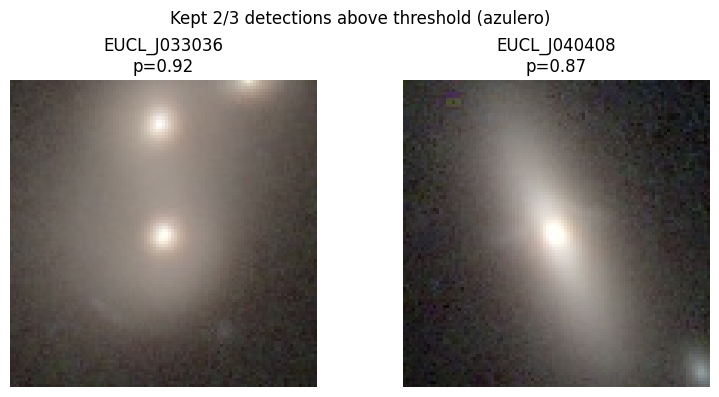

In [10]:
# --- Display the kept detections ---
kept = [r for r in results if r["kept"]]
if kept:
    fig, axes = plt.subplots(1, len(kept), figsize=(4 * len(kept), 4),
                             squeeze=False)
    for ax, r in zip(axes[0], kept):
        img_path = os.path.join(ml_out_dir, "azulero", f"{r['stem']}.jpg")
        ax.imshow(Image.open(img_path))
        ax.set_title(f"{r['stem'].replace('_lens','')}\np={r['probability']:.2f}")
        ax.axis("off")
    plt.suptitle(f"Kept {len(kept)}/3 detections above threshold (azulero)")
    plt.tight_layout()
    plt.show()
else:
    print("No detections above threshold — try lowering it.")

## API summary

| Function | Input | Output | Use case |
|---|---|---|---|
| `load_fits_cutout(path, band_order)` | FITS file path | `(4, H, W)` float32 or None | Load any multi-extension FITS cutout |
| `render_azulero(iyjh)` | `(4, H, W)` float32 | `(H, W, 3)` uint8 RGB | Single azulero colour image |
| `render_bulk_variant(variant, vis, y, j)` | per-band 2D arrays | `(H, W, 3)` uint8 RGB | Single bulk_euclid variant |
| `render_cutout(iyjh, renderers, ...)` | `(4, H, W)` float32 | `{name: RGB}` dict | Multi-renderer in one call |
| `render_fits_dir(input_dir, output_dir, ...)` | directory of FITS | `{name: count}` dict | Batch rendering with multiprocessing |

In [11]:
# --- Cleanup demo output ---
shutil.rmtree(demo_out_dir, ignore_errors=True)
shutil.rmtree(ml_out_dir, ignore_errors=True)
print("Cleaned up output dirs. demo_fits/ kept for re-runs.")

Cleaned up output dirs. demo_fits/ kept for re-runs.
